# 03 — Post-Merge Exploratory Data Analysis\n\nThis notebook explores the **quarterly state-level panel** (`quarterly_panel.csv`) built in Notebook 02.  \nGoal: verify the panel structure, visualise key variables (rate gap, lock-in share, new listings, permits), and run preliminary diagnostics before estimation.

In [2]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.05)
PAL = {"blue":"#1B3A5C", "acc":"#2E75B6", "red":"#D9534F",
       "green":"#5CB85C", "orange":"#F0AD4E", "gray":"#999999"}

PANEL = os.path.join("..", "data", "panel", "quarterly_panel.csv")
EDA   = os.path.join("..", "output", "eda_post")
os.makedirs(EDA, exist_ok=True)

df = pd.read_csv(PANEL, parse_dates=["qdate"])
df = df.sort_values(["state", "qdate"]).reset_index(drop=True)
print(f"Loaded panel: {df.shape[0]:,} rows × {df.shape[1]} cols")
df.head(3)

Loaded panel: 2,601 rows × 28 cols


,state,qdate,quarter_str,ave_intrate,pct_lt3,pct_3_4,pct_4_5,pct_5_6,pct_ge6,tot_loans,...,zhvi_yoy,new_listing_count,active_listing_count,median_days_on_market,median_listing_price,net_migration_lag1,covid_dummy,ln_permits,ln_new_listings,post_2022
0,AK,2013-01-01,2013Q1,5.0,3.5,23.3,29.1,21.9,22.1,118.0,...,4.191894,NaN,NaN,NaN,NaN,-1.822237,0,5.705197,NaN,0
1,AK,2013-04-01,2013Q2,4.9,4.4,26.4,28.7,19.9,20.6,117.0,...,3.158234,NaN,NaN,NaN,NaN,-1.822237,0,5.627459,NaN,0
2,AK,2013-07-01,2013Q3,4.8,4.6,27.2,29.8,19.0,19.4,117.0,...,3.053371,NaN,NaN,NaN,NaN,-1.822237,0,5.597718,NaN,0


---\n## 1 · Panel Structure Verification

In [3]:
# --- Dimensions ---
n_states  = df["state"].nunique()
n_quarters = df["qdate"].nunique()
print(f"States: {n_states}  |  Quarters: {n_quarters}  |  Expected rows: {n_states * n_quarters}  |  Actual rows: {len(df)}")

# --- Balance check ---
obs_per_state = df.groupby("state").size()
print(f"\nObs per state — min: {obs_per_state.min()}, max: {obs_per_state.max()}, "
      f"median: {obs_per_state.median()}")
if obs_per_state.nunique() == 1:
    print("✓ Panel is balanced.")
else:
    print("⚠ Panel is UNBALANCED. States with fewer obs:")
    print(obs_per_state[obs_per_state < obs_per_state.max()].sort_values())

States: 51  |  Quarters: 51  |  Expected rows: 2601  |  Actual rows: 2601

Obs per state — min: 51, max: 51, median: 51.0
✓ Panel is balanced.


In [4]:
# --- Missing values ---
null_pct = df.isnull().mean().mul(100).round(1)
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)
if null_pct.empty:
    print("✓ No missing values in any column.")
else:
    print("Columns with missing values (% missing):")
    print(null_pct.to_string())

Columns with missing values (% missing):
new_listing_count        27.5
active_listing_count     27.5
median_days_on_market    27.5
median_listing_price     27.5
ln_new_listings          27.5


In [5]:
# --- Summary statistics for key regression variables ---
key_vars = ["rate_gap", "share_locked_in", "ln_new_listings", "ln_permits",
            "hpi_yoy", "unemp_rate", "median_days_on_market",
            "net_migration_lag1", "zhvi_yoy"]
df[key_vars].describe().round(3)

,rate_gap,share_locked_in,ln_new_listings,ln_permits,hpi_yoy,unemp_rate,median_days_on_market,net_migration_lag1,zhvi_yoy
count,2601.000,2601.000,1887.000,2601.000,2601.000,2601.000,1887.000,2601.000,2601.000
mean,0.083,71.660,9.593,8.140,6.239,4.644,58.497,0.600,6.135
std,1.537,11.373,1.060,1.164,4.938,1.924,17.851,5.868,5.028
min,-2.496,31.600,7.132,4.916,-9.610,1.700,14.333,-16.327,-9.066
25%,-1.030,65.100,8.750,7.329,3.277,3.333,45.333,-2.962,3.086
50%,-0.622,73.700,9.695,8.265,5.037,4.200,56.667,-0.447,5.096
75%,1.645,80.300,10.376,8.867,7.422,5.433,70.000,4.521,7.952
max,3.492,93.500,11.947,11.164,32.147,24.700,156.000,27.889,39.767


---\n## 2 · Rate Gap Variable Exploration\n\n`rate_gap = ave_intrate − mortgage_rate_30yr`. A positive gap means the average existing mortgage rate is below the current market rate (homeowners are "locked in").

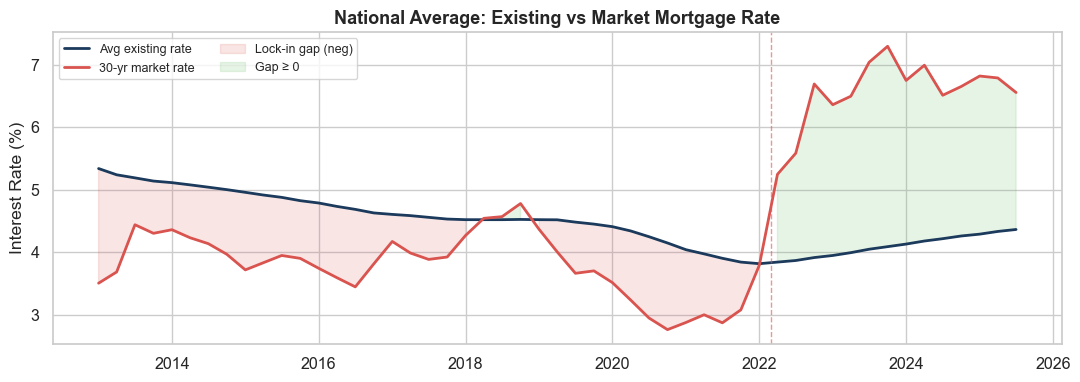

In [6]:
# 2a — National average rate_gap over time
nat = df.groupby("qdate")[["rate_gap", "ave_intrate", "mortgage_rate_30yr"]].mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(nat.index, nat["ave_intrate"], label="Avg existing rate", color=PAL["blue"], lw=2)
ax.plot(nat.index, nat["mortgage_rate_30yr"], label="30-yr market rate", color=PAL["red"], lw=2)
ax.fill_between(nat.index, nat["ave_intrate"], nat["mortgage_rate_30yr"],
                where=nat["rate_gap"] < 0, alpha=0.15, color=PAL["red"], label="Lock-in gap (neg)")
ax.fill_between(nat.index, nat["ave_intrate"], nat["mortgage_rate_30yr"],
                where=nat["rate_gap"] >= 0, alpha=0.15, color=PAL["green"], label="Gap ≥ 0")
ax.axvline(pd.Timestamp("2022-03-01"), ls="--", color=PAL["red"], alpha=0.6, lw=1)
ax.set_title("National Average: Existing vs Market Mortgage Rate", fontsize=13, fontweight="bold")
ax.set_ylabel("Interest Rate (%)")
ax.legend(fontsize=9, ncol=2)
plt.tight_layout(); plt.savefig(os.path.join(EDA, "01_rate_gap_timeseries.png"), dpi=150, bbox_inches="tight"); plt.show()

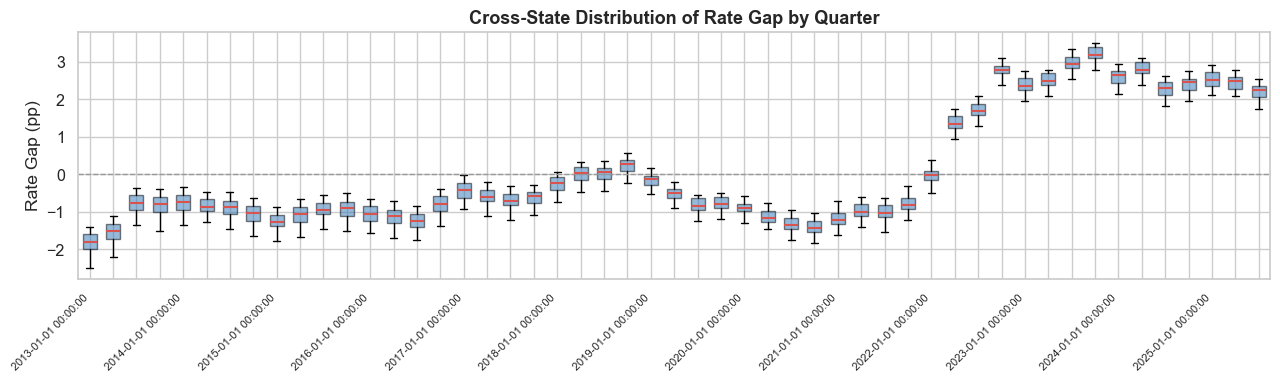

In [7]:
# 2b — Cross-state distribution of rate_gap (boxplot by quarter)
fig, ax = plt.subplots(figsize=(13, 4))
quarters = df["qdate"].sort_values().unique()
box_data = [df.loc[df["qdate"] == q, "rate_gap"].dropna().values for q in quarters]
bp = ax.boxplot(box_data, patch_artist=True, widths=0.6, showfliers=False,
                boxprops=dict(facecolor=PAL["acc"], alpha=0.5),
                medianprops=dict(color=PAL["red"], lw=1.5))
tick_labels = pd.to_datetime(quarters).strftime("%Y-Q%q")
# Show every 4th label to avoid crowding
ax.set_xticks(range(1, len(quarters)+1))
ax.set_xticklabels([lbl if i % 4 == 0 else "" for i, lbl in enumerate(tick_labels)],
                    rotation=45, ha="right", fontsize=8)
ax.axhline(0, ls="--", color=PAL["gray"], lw=1)
ax.set_ylabel("Rate Gap (pp)")
ax.set_title("Cross-State Distribution of Rate Gap by Quarter", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(EDA, "02_rate_gap_boxplot.png"), dpi=150, bbox_inches="tight"); plt.show()

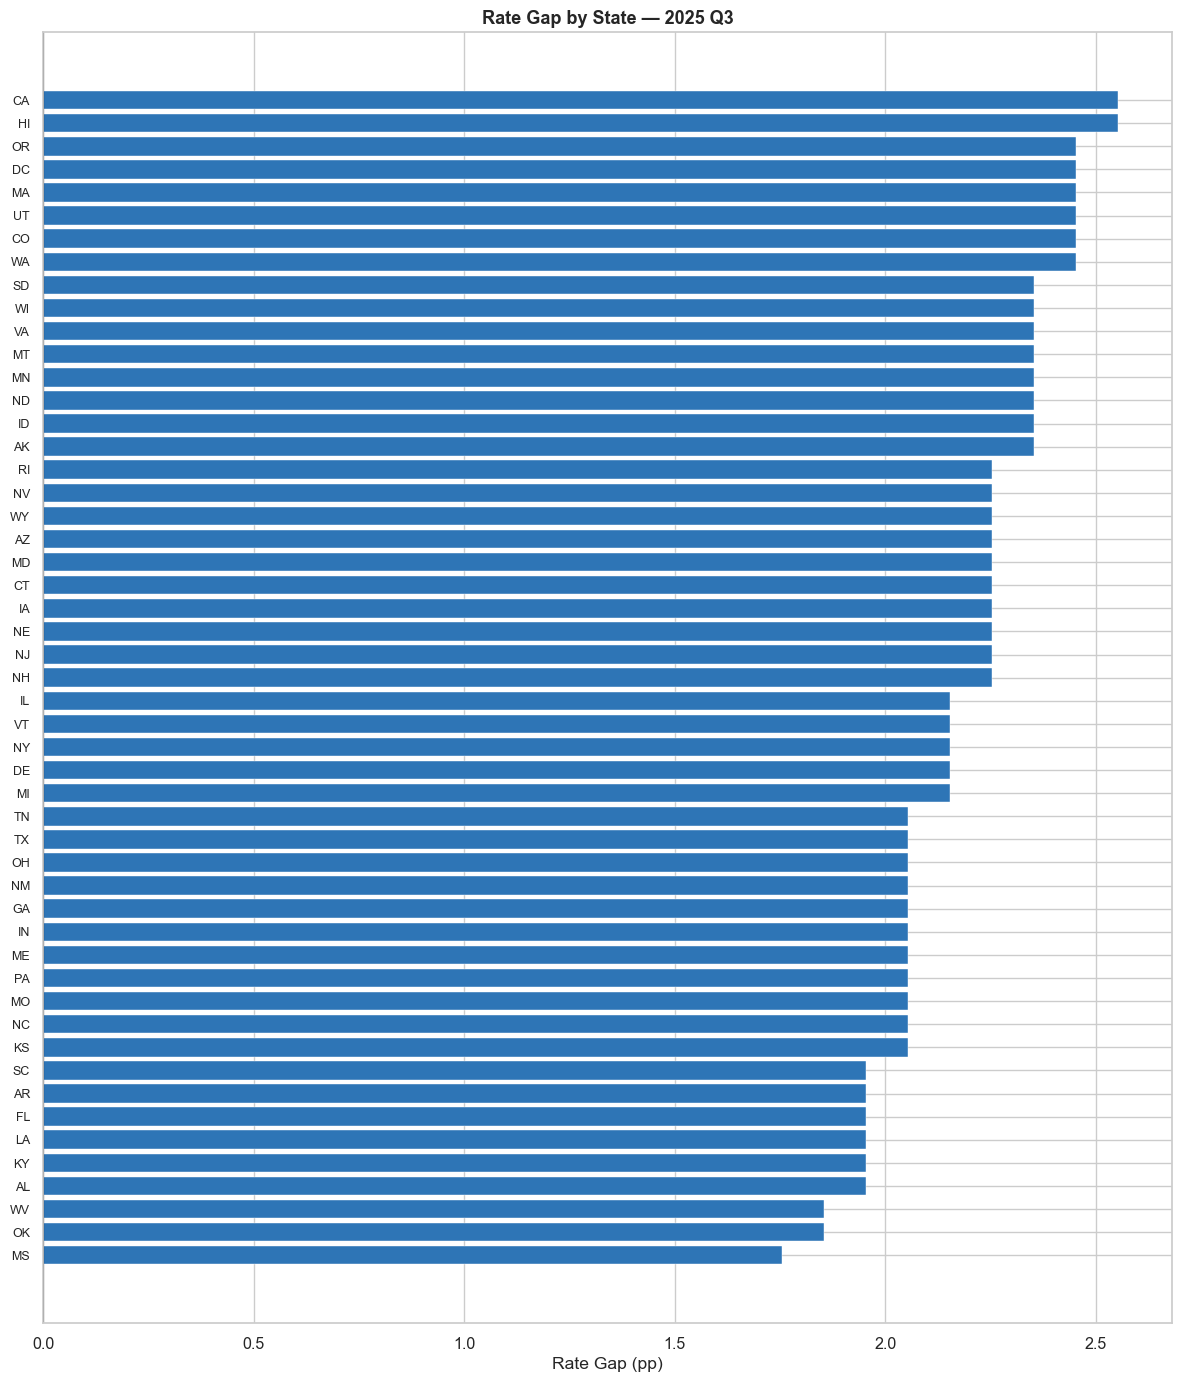

In [10]:
# 2c — Ranked bar chart: average rate_gap by state (latest available quarter)
latest_q = df["qdate"].max()
latest = df[df["qdate"] == latest_q].set_index("state")["rate_gap"].sort_values()

fig, ax = plt.subplots(figsize=(12, 14))
colors = [PAL["red"] if v < 0 else PAL["acc"] for v in latest.values]
ax.barh(latest.index, latest.values, color=colors, edgecolor="white", lw=0.3)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Rate Gap (pp)")
ax.set_title(f"Rate Gap by State — {latest_q.year} Q{(latest_q.month-1)//3+1}", fontsize=13, fontweight="bold")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout(); plt.savefig(os.path.join(EDA, "03_rate_gap_ranked.png"), dpi=150, bbox_inches="tight"); plt.show()

---\n## 3 · Dependent Variable Distributions

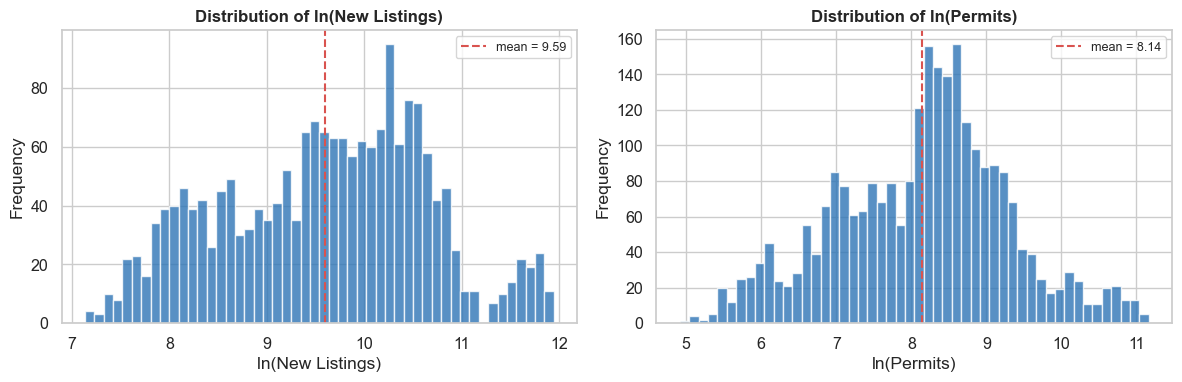

In [ ]:
# 3a — Histograms of ln_new_listings and ln_permits
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ["ln_new_listings", "ln_permits"],
                           ["ln(New Listings)", "ln(Permits)"]):
    data = df[col].dropna()
    ax.hist(data, bins=50, color=PAL["acc"], edgecolor="white", alpha=0.8)
    ax.axvline(data.mean(), color=PAL["red"], ls="--", lw=1.5, label=f"mean = {data.mean():.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
    ax.set_title(f"Distribution of {label}", fontsize=12, fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(EDA, "04_depvar_histograms.png"), dpi=150, bbox_inches="tight"); plt.show()

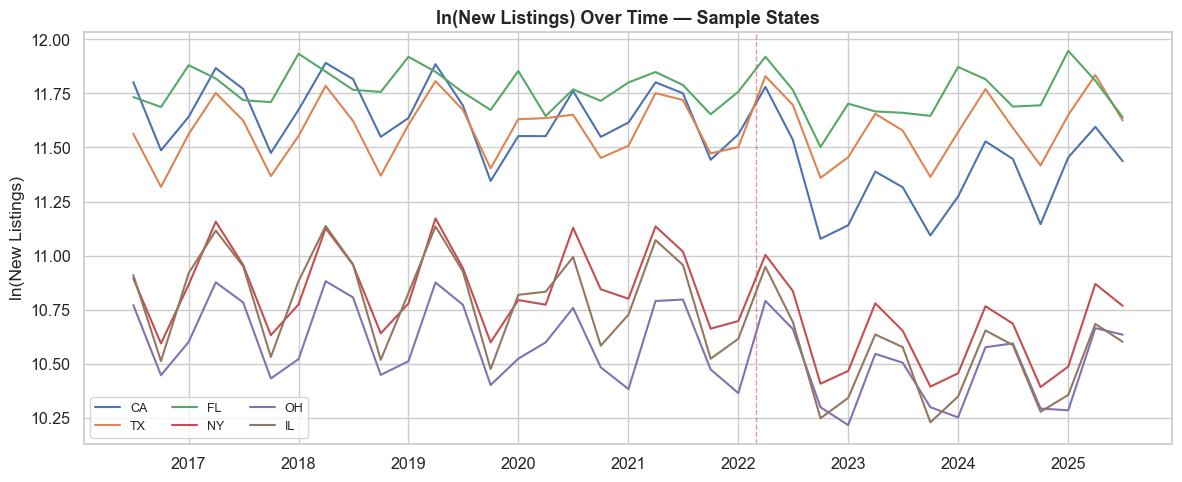

In [ ]:
# 3b — Time series of ln_new_listings for a sample of states
sample_states = ["CA", "TX", "FL", "NY", "OH", "IL"]
fig, ax = plt.subplots(figsize=(12, 5))
for st in sample_states:
    sub = df[df["state"] == st]
    ax.plot(sub["qdate"], sub["ln_new_listings"], label=st, lw=1.5)
ax.axvline(pd.Timestamp("2022-03-01"), ls="--", color=PAL["red"], alpha=0.6, lw=1)
ax.set_ylabel("ln(New Listings)")
ax.set_title("ln(New Listings) Over Time — Sample States", fontsize=13, fontweight="bold")
ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(EDA, "05_ln_listings_timeseries.png"), dpi=150, bbox_inches="tight"); plt.show()

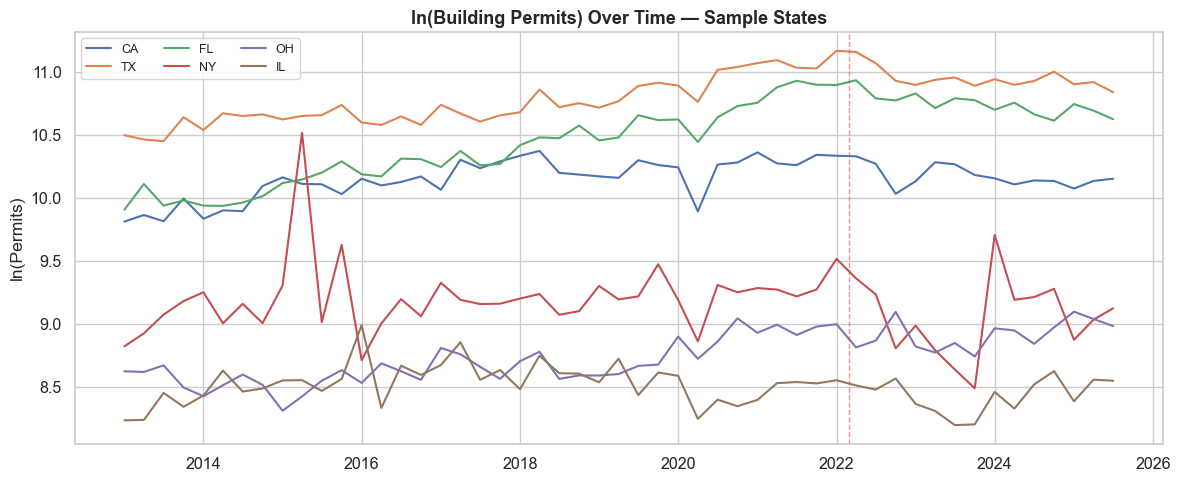

In [ ]:
# 3c — Time series of ln_permits for sample states
fig, ax = plt.subplots(figsize=(12, 5))
for st in sample_states:
    sub = df[df["state"] == st]
    ax.plot(sub["qdate"], sub["ln_permits"], label=st, lw=1.5)
ax.axvline(pd.Timestamp("2022-03-01"), ls="--", color=PAL["red"], alpha=0.6, lw=1)
ax.set_ylabel("ln(Permits)")
ax.set_title("ln(Building Permits) Over Time — Sample States", fontsize=13, fontweight="bold")
ax.legend(ncol=3, fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(EDA, "06_ln_permits_timeseries.png"), dpi=150, bbox_inches="tight"); plt.show()

---\n## 4 · Bivariate Scatter Plots (with OLS fit lines)

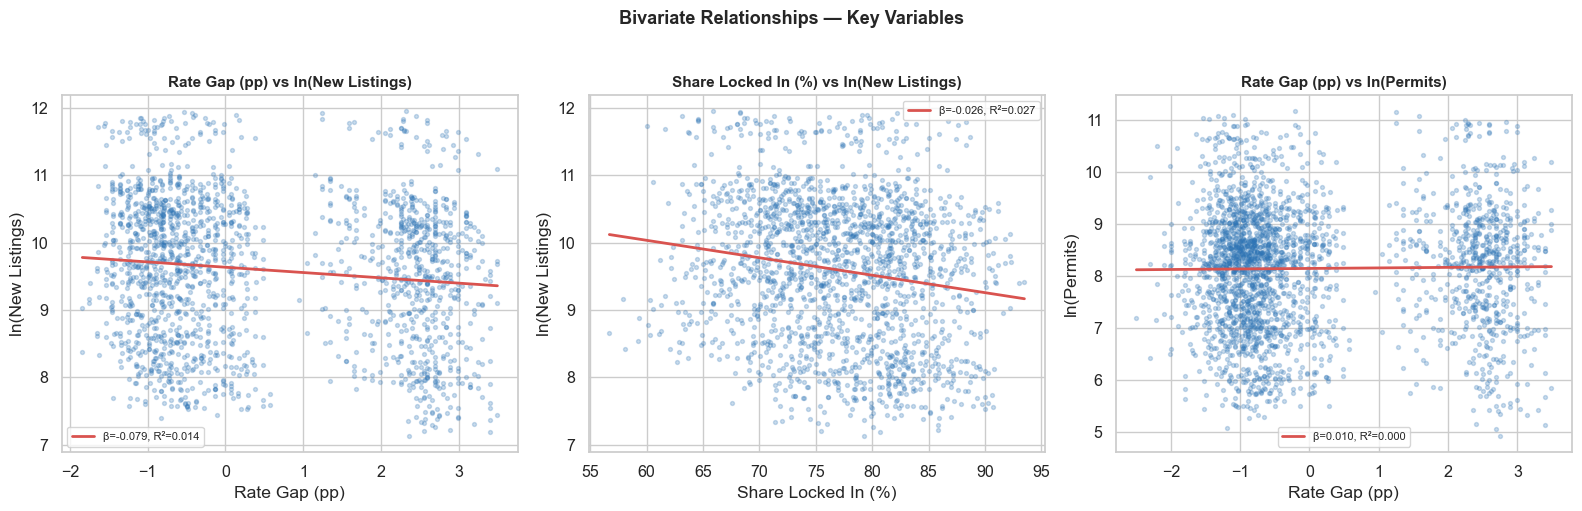

In [ ]:
scatter_pairs = [
    ("rate_gap",        "ln_new_listings", "Rate Gap (pp)",      "ln(New Listings)"),
    ("share_locked_in", "ln_new_listings", "Share Locked In (%)", "ln(New Listings)"),
    ("rate_gap",        "ln_permits",      "Rate Gap (pp)",      "ln(Permits)"),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (xvar, yvar, xlabel, ylabel) in zip(axes, scatter_pairs):
    tmp = df[[xvar, yvar]].dropna()
    ax.scatter(tmp[xvar], tmp[yvar], s=8, alpha=0.25, color=PAL["acc"])
    # OLS fit line
    slope, intercept, r, p, se = stats.linregress(tmp[xvar], tmp[yvar])
    xline = np.linspace(tmp[xvar].min(), tmp[xvar].max(), 100)
    ax.plot(xline, intercept + slope * xline, color=PAL["red"], lw=2,
            label=f"β={slope:.3f}, R²={r**2:.3f}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.set_title(f"{xlabel} vs {ylabel}", fontsize=11, fontweight="bold")

plt.suptitle("Bivariate Relationships — Key Variables", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.savefig(os.path.join(EDA, "07_bivariate_scatter.png"), dpi=150, bbox_inches="tight"); plt.show()

---\n## 5 · Correlation Matrix Heatmap

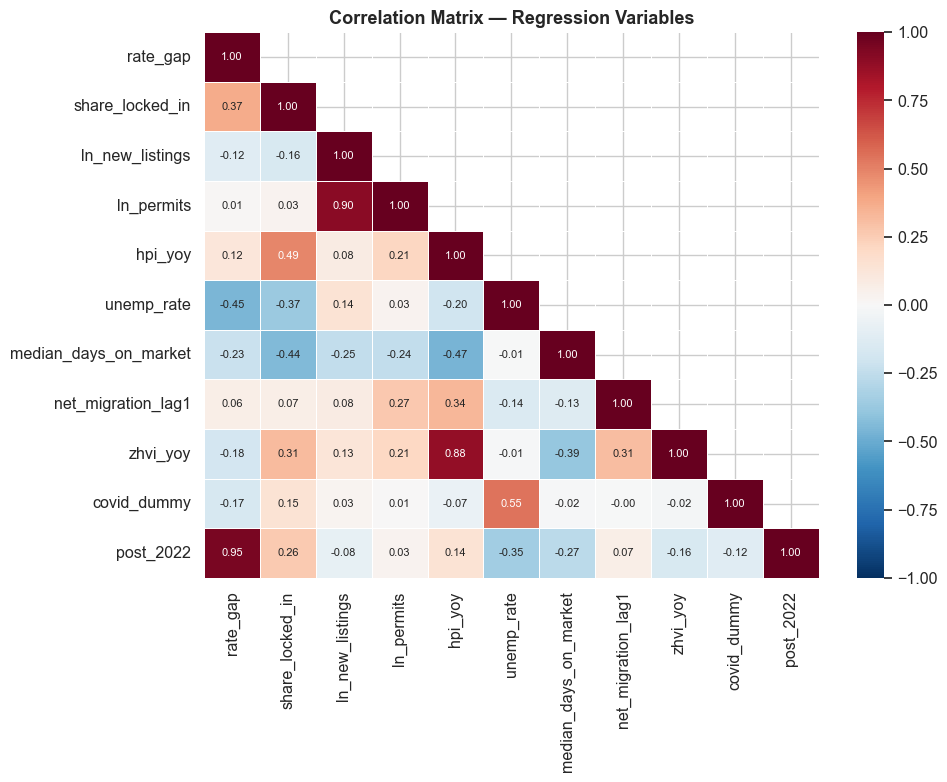

In [ ]:
# Correlation heatmap of all regression variables
reg_vars = ["rate_gap", "share_locked_in", "ln_new_listings", "ln_permits",
            "hpi_yoy", "unemp_rate", "median_days_on_market",
            "net_migration_lag1", "zhvi_yoy", "covid_dummy", "post_2022"]
corr = df[reg_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation Matrix — Regression Variables", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(EDA, "08_correlation_heatmap.png"), dpi=150, bbox_inches="tight"); plt.show()

---\n## 6 · Visual Diff-in-Diff\n\nSplit states into **top-quartile** vs **bottom-quartile** of `share_locked_in` as of 2022-Q2, then compare average new listings over time.

Top quartile (13 states): AK, CA, CO, ID, MN, MT, ND, NE, OR, SD, UT, WA, WY
Bottom quartile (13 states): AL, AR, FL, LA, MS, NM, NY, OH, OK, PA, TX, VT, WV


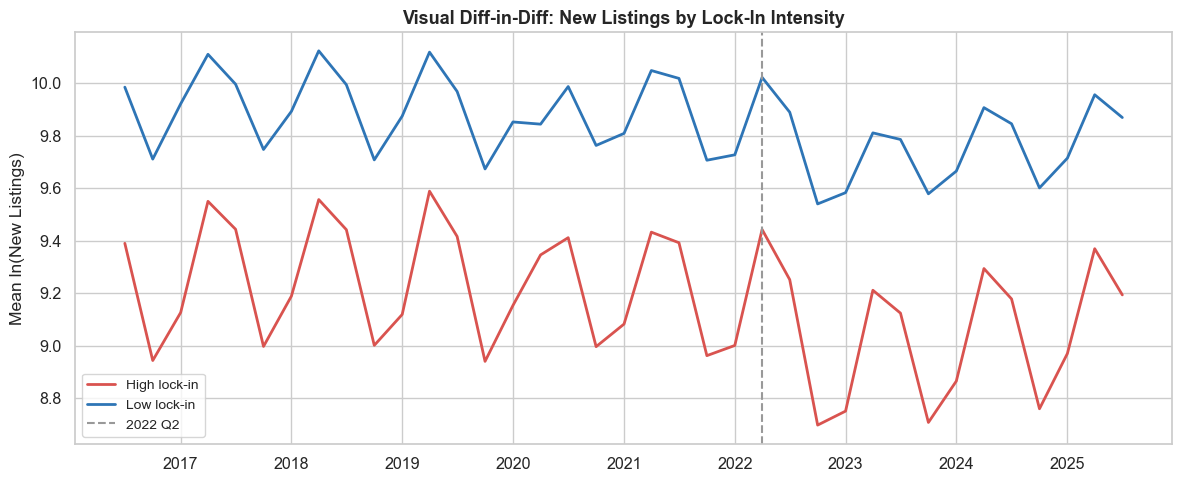

In [ ]:
# Identify 2022-Q2 share_locked_in quartiles
q2_2022 = df[df["qdate"] == "2022-04-01"].set_index("state")["share_locked_in"]
q25, q75 = q2_2022.quantile(0.25), q2_2022.quantile(0.75)
top_states = q2_2022[q2_2022 >= q75].index.tolist()
bot_states = q2_2022[q2_2022 <= q25].index.tolist()
print(f"Top quartile ({len(top_states)} states): {', '.join(sorted(top_states))}")
print(f"Bottom quartile ({len(bot_states)} states): {', '.join(sorted(bot_states))}")

# Compute group means
df["did_group"] = np.where(df["state"].isin(top_states), "High lock-in",
                  np.where(df["state"].isin(bot_states), "Low lock-in", "Middle"))
grp = (df[df["did_group"].isin(["High lock-in", "Low lock-in"])]
       .groupby(["qdate", "did_group"])["ln_new_listings"].mean().reset_index())

fig, ax = plt.subplots(figsize=(12, 5))
for label, color in [("High lock-in", PAL["red"]), ("Low lock-in", PAL["acc"])]:
    sub = grp[grp["did_group"] == label]
    ax.plot(sub["qdate"], sub["ln_new_listings"], label=label, color=color, lw=2)
ax.axvline(pd.Timestamp("2022-04-01"), ls="--", color=PAL["gray"], lw=1.5, label="2022 Q2")
ax.set_ylabel("Mean ln(New Listings)")
ax.set_title("Visual Diff-in-Diff: New Listings by Lock-In Intensity", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout(); plt.savefig(os.path.join(EDA, "09_visual_did.png"), dpi=150, bbox_inches="tight"); plt.show()

# Clean up temp column
df.drop(columns="did_group", inplace=True)

---\n## 7 · Control Variable Time Series

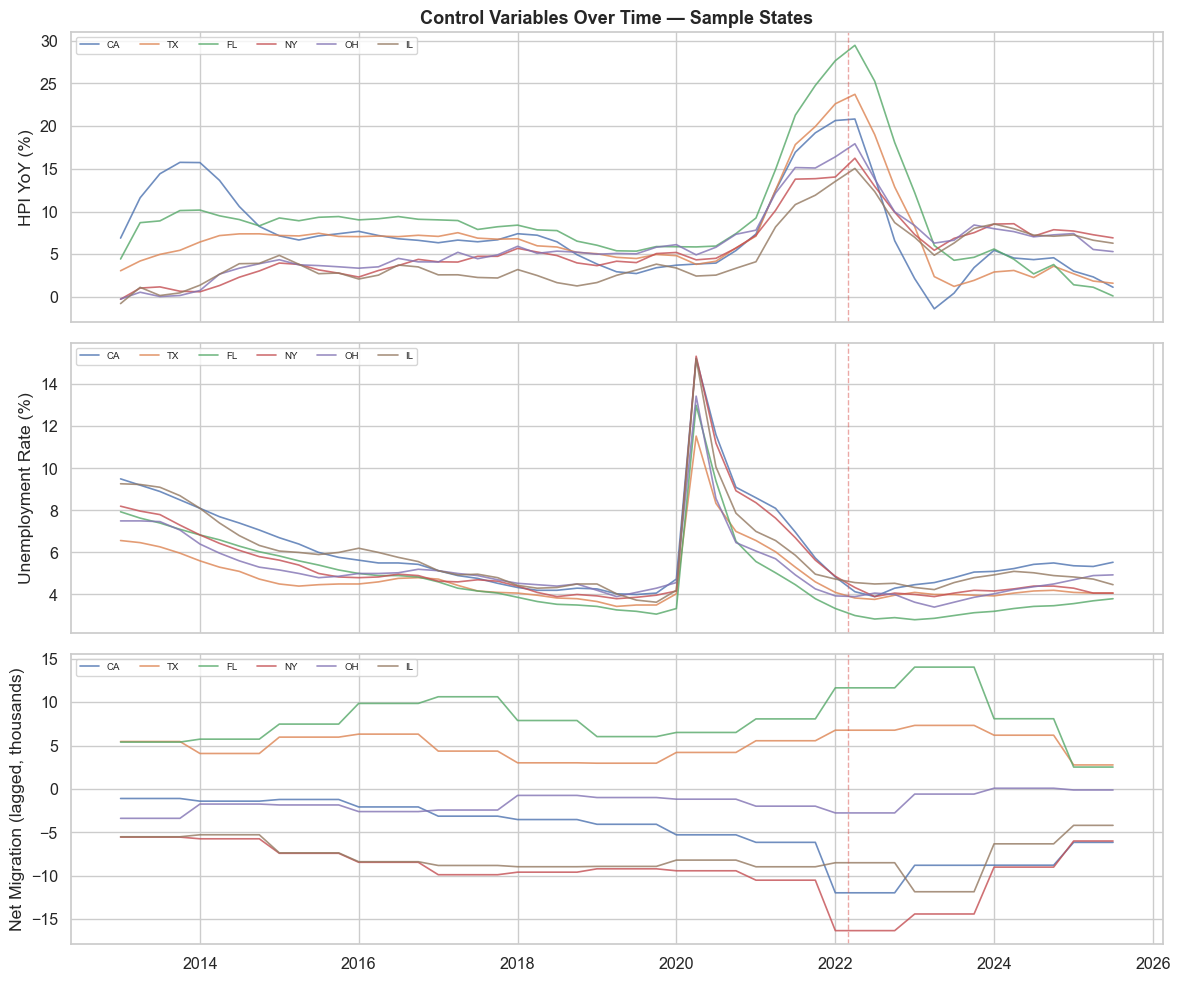

In [ ]:
# Control variables for sample states
ctrl_vars = [("hpi_yoy", "HPI YoY (%)"), ("unemp_rate", "Unemployment Rate (%)"),
             ("net_migration_lag1", "Net Migration (lagged, thousands)")]
sample_states = ["CA", "TX", "FL", "NY", "OH", "IL"]

fig, axes = plt.subplots(len(ctrl_vars), 1, figsize=(12, 10), sharex=True)
for ax, (col, label) in zip(axes, ctrl_vars):
    for st in sample_states:
        sub = df[df["state"] == st]
        ax.plot(sub["qdate"], sub[col], label=st, lw=1.2, alpha=0.8)
    ax.axvline(pd.Timestamp("2022-03-01"), ls="--", color=PAL["red"], alpha=0.5, lw=1)
    ax.set_ylabel(label)
    ax.legend(ncol=6, fontsize=7, loc="upper left")

axes[0].set_title("Control Variables Over Time — Sample States", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(EDA, "10_control_timeseries.png"), dpi=150, bbox_inches="tight"); plt.show()

---\n## 8 · Stationarity Tests (ADF)\n\nAugmented Dickey-Fuller tests on key variables for a sample of states. Null hypothesis: unit root (non-stationary).

In [ ]:
adf_vars = ["rate_gap", "ln_new_listings", "ln_permits", "hpi_yoy", "unemp_rate"]
adf_states = ["CA", "TX", "FL", "NY", "OH", "IL"]

rows = []
for st in adf_states:
    sub = df[df["state"] == st].sort_values("qdate")
    for var in adf_vars:
        series = sub[var].dropna()
        if len(series) < 8:
            continue
        stat, pval, lags, nobs, crit, _ = adfuller(series, autolag="AIC")
        rows.append({"State": st, "Variable": var,
                     "ADF Stat": round(stat, 3), "p-value": round(pval, 4),
                     "Lags": lags, "N": nobs,
                     "Stationary (5%)": "Yes" if pval < 0.05 else "No"})

adf_df = pd.DataFrame(rows)
# Pivot for cleaner display
adf_pivot = adf_df.pivot_table(index="Variable", columns="State",
                                values="p-value", aggfunc="first")
print("ADF p-values (< 0.05 → reject unit root → stationary):\n")
print(adf_pivot.round(3).to_string())
print(f"\n{adf_df['Stationary (5%)'].value_counts().to_dict()}")

ADF p-values (< 0.05 → reject unit root → stationary):

State               CA     FL     IL     NY     OH     TX
Variable                                                 
hpi_yoy          0.000  0.025  0.473  0.248  0.288  0.153
ln_new_listings  0.481  0.174  0.892  0.566  0.850  0.086
ln_permits       0.007  0.439  0.011  0.000  0.800  0.728
rate_gap         0.895  0.741  0.728  0.889  0.856  0.744
unemp_rate       0.028  0.018  0.006  0.018  0.003  0.011

{'No': 19, 'Yes': 11}


---\n## Summary

In [ ]:
print("Diagnostic plots saved to output/eda_post/:")
for f in sorted(os.listdir(EDA)):
    if f.endswith(".png"):
        print(f"  {f}")

Diagnostic plots saved to output/eda_post/:
  01_rate_gap_timeseries.png
  02_rate_gap_boxplot.png
  04_depvar_histograms.png
  05_ln_listings_timeseries.png
  06_ln_permits_timeseries.png
  07_bivariate_scatter.png
  08_correlation_heatmap.png
  09_visual_did.png
  10_control_timeseries.png


## Key Findings

### 1. The Lock-In Effect Is Confirmed in the Data
The rate gap was **negative** (-1.0 pp on average) throughout 2013–2021, meaning homeowners held above-market rates and faced no financial penalty for selling. The gap flipped **positive** in early 2022 and peaked at approximately **+3.0 pp** by late 2023, before moderating to roughly **+2.0 pp** by 2025 Q3. The shift was abrupt — occurring over just 2–3 quarters — and affected every state simultaneously. This sharp onset strengthens the quasi-experimental identification strategy.

### 2. Cross-State Variation Is Substantial and Economically Meaningful
The rate gap in the latest quarter ranges from approximately **0.0 pp** (Mississippi, Oklahoma) to **2.6 pp** (California, Oregon). This 2.5 pp spread translates to a monthly payment difference of over **$500** on a typical mortgage, providing strong economic motivation for differential listing behavior across states. The most locked-in states are concentrated in the **West Coast and Mountain West** (pandemic boom states with large volumes of ultra-low-rate originations), while the least locked-in are in the **South and Appalachia**.

### 3. Florida and Texas Are NOT Among the Most Locked-In States
Despite having massive pandemic housing booms, Florida and Texas fall in the **bottom quartile** of share-locked-in. Their large pre-pandemic housing stock and continued high transaction volumes dilute the sub-5% mortgage cohort faster than smaller states like Montana, Idaho, or South Dakota. This is analytically valuable — it means the lock-in variable captures something **distinct from "pandemic boom state" status**, which helps address the confound between lock-in and post-boom hangover.

### 4. Bivariate Relationships Are Directionally Correct but Weak
- **Rate Gap vs. ln(New Listings):** β = -0.079, R² = 0.014 (negative, as expected)
- **Share Locked-In vs. ln(New Listings):** β = -0.026, R² = 0.027 (negative, as expected)
- **Rate Gap vs. ln(Permits):** β = 0.010, R² ≈ 0.000 (flat — expected given theoretical ambiguity)

The weak R² values are **not concerning** — these are raw bivariate correlations dominated by cross-state size differences (Texas vs. Wyoming). Two-way fixed effects will absorb permanent state differences and common time shocks, typically strengthening the estimated relationship substantially.

### 5. No Multicollinearity Among Controls
No pair of control variables entering the same regression exceeds r = 0.49. The highest correlation in the matrix is **HPI YoY ↔ ZHVI YoY at 0.88**, but these are alternative measures never used simultaneously. The **rate_gap ↔ post_2022 correlation of 0.95** reflects the structural break timing (nearly all rate gap variation occurs post-2022) rather than a multicollinearity problem between regressors.

### 6. Parallel Trends Hold in Slopes but Not Levels
The visual diff-in-diff shows that high lock-in and low lock-in state groups maintain a **persistent level gap** throughout the pre-period (high lock-in states list fewer homes on average). However, the **gap is stable** — the lines do not converge or diverge before 2022, and both groups exhibit identical seasonal patterns. This means:
- **Parallel trends in levels: violated** (different starting points)
- **Parallel trends in growth rates: supported** (stable gap, same slope)
- **Implication:** State fixed effects (which absorb level differences) are essential. Model R3 must include state FE or normalize to the treatment date.

### 7. Unit Root Concerns for Key Variables
- **rate_gap:** Non-stationary in all 6 tested states (structural shift in 2022)
- **ln_new_listings:** Non-stationary in 5 of 6 states
- **unemp_rate:** Stationary in all 6 states
- **hpi_yoy and ln_permits:** Mixed results

Both the primary IV and DV exhibit unit roots, creating a **risk of spurious regression** in levels. Two-way fixed effects with state and time dummies mitigate this, but a **first-differenced robustness check** is necessary.

### 8. Log Transform Is Appropriate
Both ln(New Listings) and ln(Permits) show approximately **bell-shaped distributions**, substantially reducing the right skew present in raw counts. OLS normality assumptions are reasonably satisfied.

---

## Implications for the Regression

| Finding | Implication for Regression |
|---------|---------------------------|
| Sharp rate gap onset in 2022 | Strong quasi-experimental identification; time FE absorb common shock |
| 2.5 pp cross-state spread | Sufficient variation for state-specific coefficient estimation (Model C) |
| FL and TX in low lock-in group | Lock-in variable is distinct from boom status; pandemic boom control (R4) may be less critical than expected |
| Weak raw bivariate slopes | Expected — FE will strengthen; do not interpret raw R² as predictive power |
| No multicollinearity | All controls can enter simultaneously; VIF test in regression should confirm |
| Parallel trends in growth only | State FE mandatory in all models; normalize diff-in-diff to treatment date |
| Unit roots in rate_gap and DV | Add first-differenced specification as robustness check |

---

## Adjustments to the Methodology Based on EDA

### Addition: First-Differenced Model (R6)
Given the ADF results, add a first-differenced robustness check:

> Δln(NewListings_it) = β₁(ΔRateGap_it) + β₂(ΔHPI_YoY_it) + β₃(ΔUnempRate_it) + β₄(ΔMedianDOM_it) + δ_t + ε_it

This differences out state fixed effects automatically and addresses the unit root concern. If results are consistent with Model A in levels, the non-stationarity is not driving the findings.

### Adjustment: Diff-in-Diff Normalization
Model R3 should either:
- Include state fixed effects within the DiD framework, or
- Normalize both groups to index = 100 at 2022 Q2 and compare percent changes

The raw level comparison shown in the visual DiD is misleading because the groups start at different heights.

### Confirmed: No Changes Needed For
- **Control variable selection:** No multicollinearity issues; all controls remain in the primary specification
- **Log transformation:** Confirmed appropriate for both DVs
- **Quarterly frequency:** Rate gap shows clean quarterly variation with no forward-fill artifacts
- **COVID dummy:** The 2020 disruption is visible in both groups' seasonal patterns and needs to be absorbed

---

## Next Steps

### Immediate: Regression Notebook (04_regression.ipynb)
1. **Install `linearmodels`** (`pip install linearmodels`) for panel fixed effects estimation
2. **Estimate Model A** (primary): ln(New Listings) with two-way FE, clustered SE by state
3. **Estimate Model B** (secondary): ln(Permits) with two-way FE
4. **Estimate Model C** (heterogeneous): 51 state-specific rate gap coefficients → state ranking
5. **Run robustness suite** (R1–R5 plus new R6 first-differenced)
6. **Diagnostic tests:** Hausman test, VIF, Breusch-Pagan, within-R² reporting
7. **Economic magnitude calculation:** translate β₁ into "X fewer listings per pp of rate gap"

### Subsequent: Visualization & Deliverables
8. **Choropleth map** of state-specific lock-in coefficients from Model C
9. **Publication-quality regression tables** (side-by-side Models A, B, R1–R6)
10. **Power BI dashboard** using `quarterly_panel.csv`
11. **Final report** synthesizing all findings

### Analytical Decisions Still Pending
- If first-differenced model (R6) contradicts levels model (A) → investigate further; may need error correction model
- If Model C state coefficients are too noisy (wide confidence intervals) → consider grouping states into regions instead of individual estimates
- If permits model (B) remains flat after FE → confirm in write-up that lock-in operates primarily through the existing-home channel, not new construction
